# RNN - Recurrent Neural Network (TensorFlow / Keras)

An RNN processes a sequence one token at a time, carrying a **hidden state** forward
so later tokens are interpreted in the context of earlier ones — useful for text,
where word order matters.

We classify real newsgroup posts into one of two topics, **hockey vs. space**, using
`sklearn.datasets.fetch_20newsgroups`: a simple word-level tokenizer + vocabulary,
an embedding layer, and a plain `SimpleRNN`.

In [1]:
import re
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import fetch_20newsgroups

tf.random.set_seed(0)

categories = ["rec.sport.hockey", "sci.space"]
train = fetch_20newsgroups(subset="train", categories=categories,
                            remove=("headers", "footers", "quotes"))
test = fetch_20newsgroups(subset="test", categories=categories,
                           remove=("headers", "footers", "quotes"))
len(train.data), len(test.data), train.target_names

(1193, 793, ['rec.sport.hockey', 'sci.space'])

In [2]:
MAX_VOCAB = 5000
MAX_LEN = 150


def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


train_tokens = [tokenize(doc) for doc in train.data]
test_tokens = [tokenize(doc) for doc in test.data]

counter = Counter(tok for toks in train_tokens for tok in toks)
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(MAX_VOCAB - len(vocab)):
    vocab[word] = len(vocab)


def encode(tokens):
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:MAX_LEN]
    ids += [vocab["<pad>"]] * (MAX_LEN - len(ids))
    return ids


X_train = np.array([encode(t) for t in train_tokens], dtype="int32")
X_test = np.array([encode(t) for t in test_tokens], dtype="int32")
y_train = train.target.astype("float32")
y_test = test.target.astype("float32")

vocab_size = len(vocab)
X_train.shape, vocab_size

((1193, 150), 5000)

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(MAX_LEN,)),
    tf.keras.layers.Embedding(vocab_size, 32, mask_zero=True),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,113 (633.25 KB)

 Trainable params: 162,113 (633.25 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(X_train, y_train, epochs=30, verbose=1)

Epoch 1/30


 1/38 ━━━━━━━━━━━━━━━━━━━━ 26s 708ms/step - accuracy: 0.5000 - loss: 0.7031

 8/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5010 - loss: 0.7182   

15/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4999 - loss: 0.7162

21/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5036 - loss: 0.7123

...

14/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9798 - loss: 0.0188

21/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9819 - loss: 0.0176

29/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9833 - loss: 0.0171

36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9839 - loss: 0.0172

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9866 - loss: 0.0187


Test accuracy: 0.556


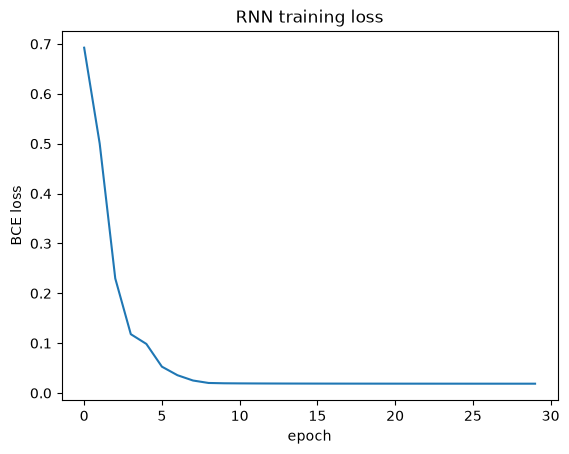

In [5]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")

plt.plot(history.history["loss"])
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("RNN training loss")
plt.show()